In [7]:
import shutil

import duckdb
import pandas as pd
from networks.oligoclonal_network import OligoclonalModel


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, interpretation,label
                 FROM protein_data
                 WHERE observation_nr = 1
                 """).df()
con.close()

correct_label = df['label'] == 6

valid_text = df['interpretation'].apply(lambda x: 1 if 'oligoklonal' in str(x).lower() else 0)
df['label'] = ((correct_label) | (valid_text)).astype(int)


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

extra_val = train_rows.sample(frac=0.2, random_state=42)
train_rows = train_rows.drop(extra_val.index)
val_rows = pd.concat([val_rows, extra_val], ignore_index=True)

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.8).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan oligoklonalt-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med oligoklonalt i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

print(f"-----\nAntal utan oligoklonalt i valideringsdatan: {len(val_rows[val_rows['label'] == 0])}")
print(f"Antal med oligoklonalt i valideringsdatan: {len(val_rows[val_rows['label'] == 1])}")

print(f"-----\nAntal utan oligoklonalt i valideringsdatan: {len(test_rows[test_rows['label'] == 0])}")
print(f"Antal med oligoklonalt i valideringsdatan: {len(test_rows[test_rows['label'] == 1])}")

Oligoclonal = OligoclonalModel()
train_dl = Oligoclonal.build_dataloader(train_rows)
val_dl = Oligoclonal.build_dataloader(val_rows)
test_dl = Oligoclonal.build_dataloader(test_rows)



Antal utan oligoklonalt-komponent i träningsdatan: 10257
Antal med oligoklonalt i träningsdatan: 1899
-----
Antal utan oligoklonalt i valideringsdatan: 16226
Antal med oligoklonalt i valideringsdatan: 560
-----
Antal utan oligoklonalt i valideringsdatan: 7546
Antal med oligoklonalt i valideringsdatan: 254


In [ ]:
results = []

best_auc = -1
best_run = None

for run in range(10):
    print(f"Körning {run+1}/10")

    Oligoclonal = OligoclonalModel()


    auc = Oligoclonal.retrain(
        train_dl=train_dl,
        val_dl=val_dl,
        patience=10,
        model_path=f"../models/temp_oligoclonal_{run}.pth"
    )

    results.append({
        "run": run + 1,
        "val_auc": auc
    })

    if auc > best_auc:
        best_auc = auc
        best_run = run + 1
        print(Oligoclonal.model_path)
        shutil.copy(
            f"../models/temp_oligoclonal_{run}.pth",
            Oligoclonal.model_path
        )

result_df = pd.DataFrame(results)
result_df.to_csv("../results/oligoclonal_runs.csv", index=False)

print(result_df)
print(f"Bästa körning: {best_run}")
print(f"Bästa val AUC: {best_auc:.4f}")

In [8]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, interpretation,label
                 FROM protein_data
                 WHERE  observation_nr = 1
                 """).df()
con.close()

correct_label = df['label'] == 6

valid_text = df['interpretation'].apply(lambda x: 1 if 'oligoklonal' in str(x).lower() else 0)
df['label'] = ((correct_label) | (valid_text)).astype(int)



k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.8).index
k_fold_rows = k_fold_rows.drop(drop_indices)

print(f"Totalt antal utan oligoklonalt i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med oligoklonalt i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

Oligoclonal = OligoclonalModel()
Oligoclonal.retrain_with_k_fold(k_fold_rows)

Totalt antal utan oligoklonalt i K-fold poolen: 13503
Totalt antal med oligoklonalt i K-fold poolen: 2459
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   0 | train: 0.6442 | val: 0.6136 | acc: 76.14% | AUC: 0.746  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   1 | train: 0.5842 | val: 0.6021 | acc: 78.71% | AUC: 0.787  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   2 | train: 0.5691 | val: 0.5682 | acc: 67.25% | AUC: 0.814  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   3 | train: 0.5181 | val: 0.4556 | acc: 87.73% | AUC: 0.888  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   4 | train: 0.4054 | val: 0.4003 | acc: 73.58% | AUC: 0.910  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   5 | tra

,fold,train_loss,val_loss,val_accuracy,val_auc
0,1,0.228279,0.302220,86.161553,0.941756
1,2,0.305925,0.368946,90.294302,0.936987
2,3,0.222011,0.543177,81.328321,0.915453
3,4,0.236034,0.298208,83.270677,0.933126
4,5,0.278573,0.438592,86.215539,0.926254
5,6,0.278373,0.365930,86.152882,0.922087
6,7,0.247522,0.346082,85.964912,0.935381
7,8,0.245398,0.357161,84.962406,0.931486
8,9,0.258512,0.346110,87.656642,0.921442
9,10,0.222406,0.304631,82.644110,0.934428


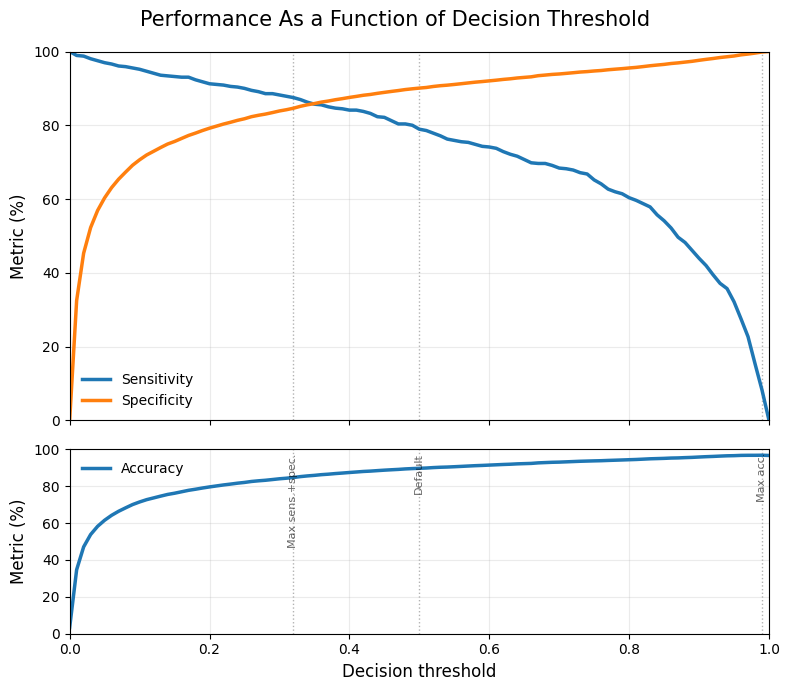

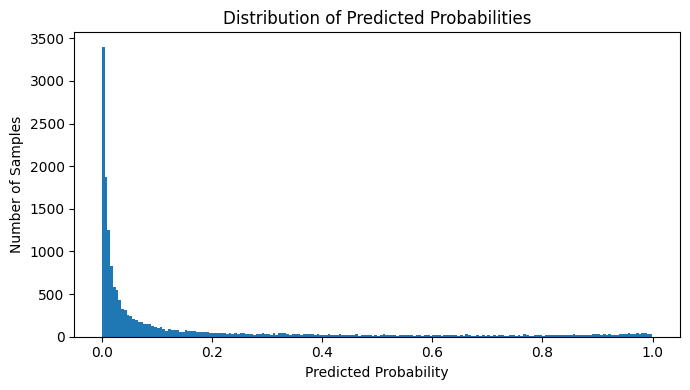

In [11]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
result = Oligoclonal.predict(val_rows)

probs  = np.array(result['oligoclonal_probability'])
labels = np.array(result['label'])

fpr, tpr, _ = roc_curve(labels, probs)

thresholds = np.linspace(0, 1, 101)
rows = []
for threshold in thresholds:
    
    preds = (probs > threshold).astype(int) 

    fp = sum((labels == 0) & (preds == 1))
    fn = sum((labels == 1) & (preds == 0))
    tn = sum((labels == 0) & (preds == 0))
    tp = sum((labels == 1) & (preds == 1))


    fn_rate = fn / sum(labels == 1)
    fp_rate = fp / sum(labels == 0)
    accuracy = sum(preds == labels) / len(preds)
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    rows.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "fn_rate": fn_rate,
        "fp_rate": fp_rate,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    })
threshold_df = pd.DataFrame(rows)


plot_df = threshold_df.copy()

# Omvandla till procent
for col in ["accuracy", "sensitivity", "specificity",
            "fp_rate", "fn_rate"]:
    plot_df[col] *= 100

# Viktiga trösklar
t_default = 0.5
t_acc = plot_df.loc[plot_df["accuracy"].idxmax(), "threshold"]
t_bal = plot_df.loc[
    (plot_df["sensitivity"] + plot_df["specificity"]).idxmax(),
    "threshold"
]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# ----------------------------
# Övre panel
# ----------------------------

ax1.plot(
    plot_df["threshold"],
    plot_df["sensitivity"],
    lw=2.5,
    label="Sensitivity"
)

ax1.plot(
    plot_df["threshold"],
    plot_df["specificity"],
    lw=2.5,
    label="Specificity"
)

ax1.set_ylabel("Metric (%)", fontsize=12)
ax1.set_ylim(0, 100)
ax1.grid(alpha=0.25)
ax1.legend(frameon=False)

# ----------------------------
# Nedre panel
# ----------------------------

ax2.plot(
    plot_df["threshold"],
    plot_df["accuracy"],
    lw=2.5,
    label="Accuracy"
)


ax2.set_xlabel("Decision threshold", fontsize=12)
ax2.set_ylabel("Metric (%)", fontsize=12)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 100)
ax2.grid(alpha=0.25)
ax2.legend(frameon=False)

# ----------------------------
# Diskreta markeringar
# ----------------------------

markers = [
    (t_default, "Default"),
    (t_acc, "Max acc."),
    (t_bal, "Max sens.+spec.")
]

for ax in [ax1, ax2]:
    for x, _ in markers:
        ax.axvline(
            x,
            color="black",
            linestyle=":",
            linewidth=1,
            alpha=0.3,
            zorder=0
        )

# Text endast i nedersta figuren
for x, text in markers:
    ax2.text(
        x,
        98,
        text,
        rotation=90,
        fontsize=8,
        alpha=0.6,
        ha="center",
        va="top"
    )

plt.suptitle(
    "Performance As a Function of Decision Threshold",
    fontsize=15,
    y=0.98
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))

plt.hist(probs, bins=200)
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Samples")
plt.title("Distribution of Predicted Probabilities")

plt.tight_layout()
plt.show()

Totala mängd datapunkter: 16786
              precision    recall  f1-score   support

     Negativ       0.99      0.90      0.94     16226
     Positiv       0.22      0.79      0.34       560

    accuracy                           0.90     16786
   macro avg       0.60      0.85      0.64     16786
weighted avg       0.97      0.90      0.92     16786

[[14616  1610]
 [  118   442]]
AUC: 0.927677140744132
Accuracy:  89.71%
FN-rate:   21.07%  (farliga missade fall)
FP-rate:   9.92%  (onödiga larm)
Sensitivitet:   78.93%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   90.08%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9277


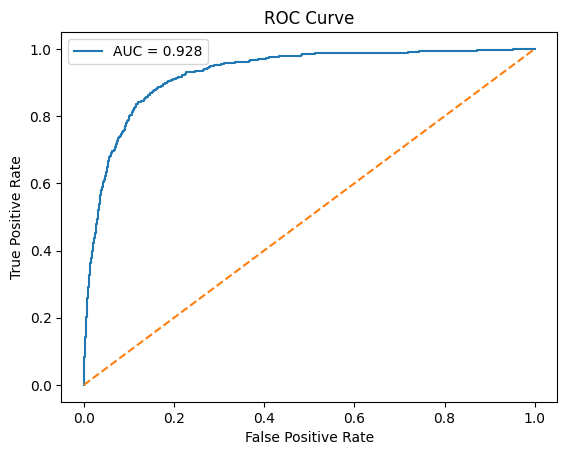

In [ ]:
df = Oligoclonal.predict(test_rows)
df = Oligoclonal.evaluate(test_rows,threshold=0.5)
